<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-01-11 04:42:07--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  55.5MB/s    in 3.7s    

2026-01-11 04:42:13 (54.6 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 175.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 167.3 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 115.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 135.1 MB/s eta 0:00:00


In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


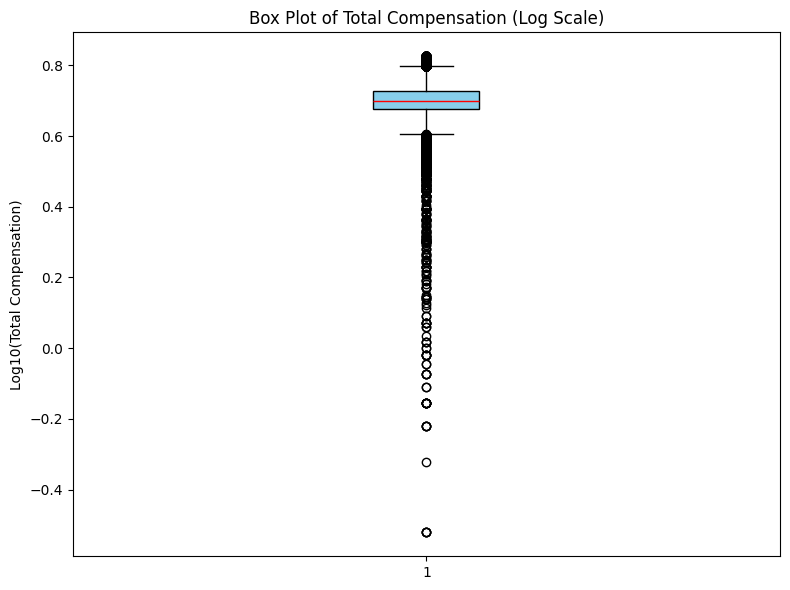

In [10]:
# your code goes here
# Load data
QUERY = "SELECT CompTotal FROM main"
df = pd.read_sql_query(QUERY, conn)

# Convert to numeric and clean
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")
df = df[df["CompTotal"] > 0].dropna(subset=["CompTotal"])

# Optional: cap extreme outliers to avoid distortion
df = df[df["CompTotal"] <= 5_000_000]

# Log-transform compensation
df["LogCompTotal"] = np.log10(df["CompTotal"])

comp = df["LogCompTotal"].dropna()
comp = comp[comp > 0]

plt.figure(figsize=(8, 6))

plt.boxplot(
    np.log10(comp),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="skyblue"),
    medianprops=dict(color="red")
)

plt.ylabel("Log10(Total Compensation)")
plt.title("Box Plot of Total Compensation (Log Scale)")

plt.tight_layout()
plt.show()
##Even after applying a logarithmic transformation, total compensation shows substantial inequality. Most respondents earn within a 
##narrow range around the median, while a significant number earn much less and a small number earn considerably more.

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


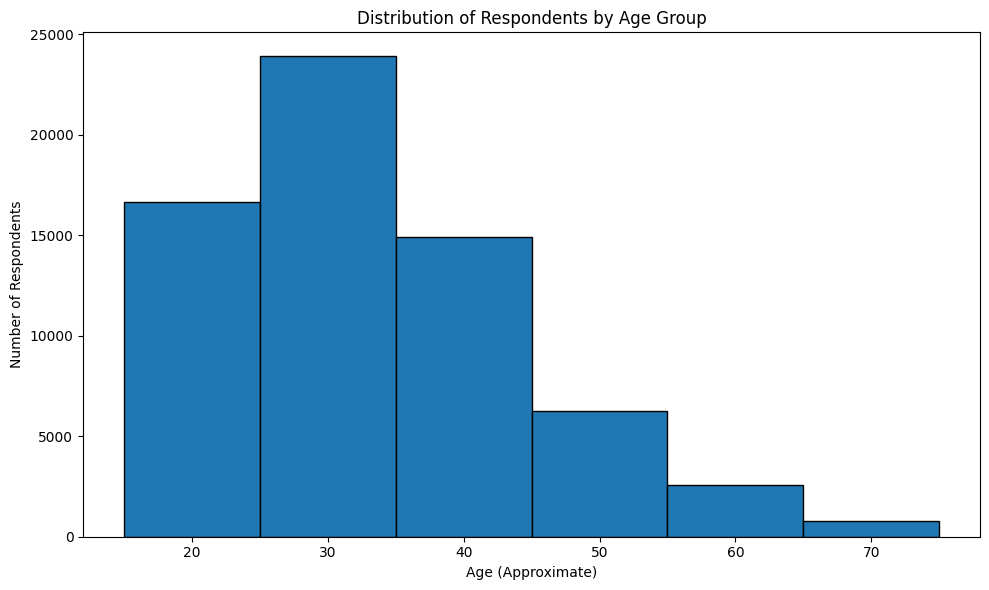

In [11]:
# your code goes here
# Run a simple query to check the data
QUERY = "SELECT Age FROM main"
df = pd.read_sql_query(QUERY, conn)
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df["Age_Num"] = df["Age"].map(age_map)
age_numeric = df["Age_Num"].dropna()
plt.figure(figsize=(10, 6))

plt.hist(
    age_numeric,
    bins=[15, 25, 35, 45, 55, 65, 75],
    edgecolor="black"
)

plt.xlabel("Age (Approximate)")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Respondents by Age Group")

plt.xticks([20, 30, 40, 50, 60, 70])
plt.tight_layout()
plt.show()
##The age distribution shows that most respondents fall between 25 and 44 years old,
##indicating a predominantly early- to mid-career population, with fewer participants at the youngest and oldest age ranges.

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


<Figure size 1200x600 with 0 Axes>

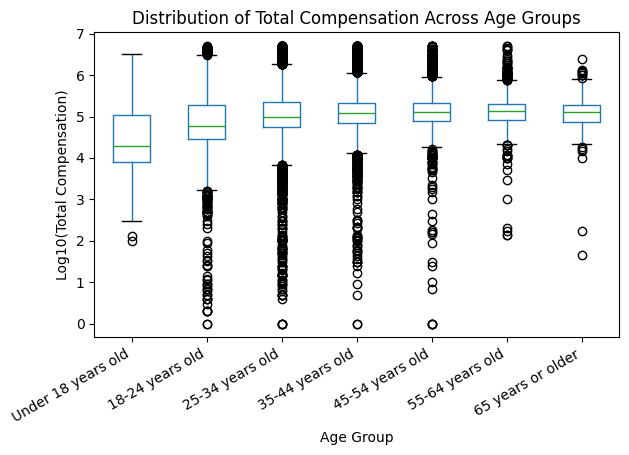

In [12]:
# your code goes here
# Load required columns
QUERY = "SELECT Age, CompTotal FROM main"
df = pd.read_sql_query(QUERY, conn)

# Convert compensation to numeric
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")

# Drop invalid values
df = df.dropna(subset=["Age", "CompTotal"])
df = df[df["CompTotal"] > 0]

# Optional: cap extreme outliers for readability
df = df[df["CompTotal"] <= 5_000_000]

# Log-transform compensation
df["LogCompTotal"] = np.log10(df["CompTotal"])
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

df["Age"] = pd.Categorical(df["Age"], categories=age_order, ordered=True)
plt.figure(figsize=(12, 6))

df.boxplot(
    column="LogCompTotal",
    by="Age",
    grid=False
)

plt.xlabel("Age Group")
plt.ylabel("Log10(Total Compensation)")
plt.title("Distribution of Total Compensation Across Age Groups")
plt.suptitle("")  # removes automatic subtitle
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
##The box plot shows that total compensation generally increases with age, with older age groups exhibiting 
##higher median compensation and greater variability. Younger respondents tend to earn less, 
##while older groups show a wider spread and more high-income outliers, reflecting increased experience and role diversity.

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


<Figure size 1000x600 with 0 Axes>

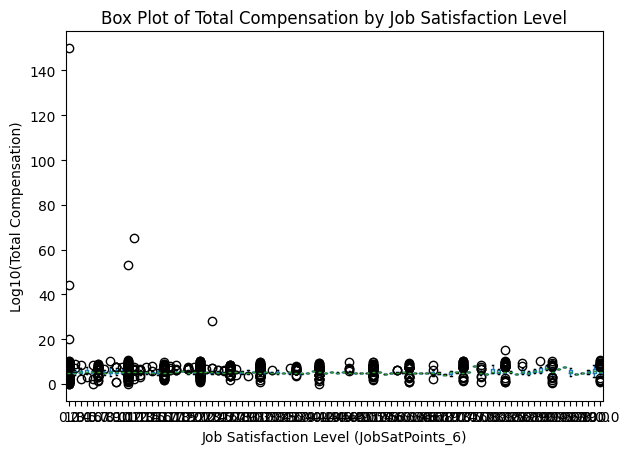

In [18]:
# your code goes here
QUERY = "SELECT JobSatPoints_6, CompTotal FROM main"
df = pd.read_sql_query(QUERY, conn)

# Ensure CompTotal is numeric
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")

# Drop invalid rows
df_plot = df.dropna(subset=["CompTotal", "JobSatPoints_6"]).copy()
df_plot = df_plot[df_plot["CompTotal"] > 0]

# Optional but recommended: log-transform compensation
df_plot["LogCompTotal"] = np.log10(df_plot["CompTotal"])
plt.figure(figsize=(10, 6))

df_plot.boxplot(
    column="LogCompTotal",
    by="JobSatPoints_6",
    grid=False
)

plt.xlabel("Job Satisfaction Level (JobSatPoints_6)")
plt.ylabel("Log10(Total Compensation)")
plt.title("Box Plot of Total Compensation by Job Satisfaction Level")
plt.suptitle("")  # remove automatic pandas subtitle
plt.tight_layout()
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


<Figure size 1200x600 with 0 Axes>

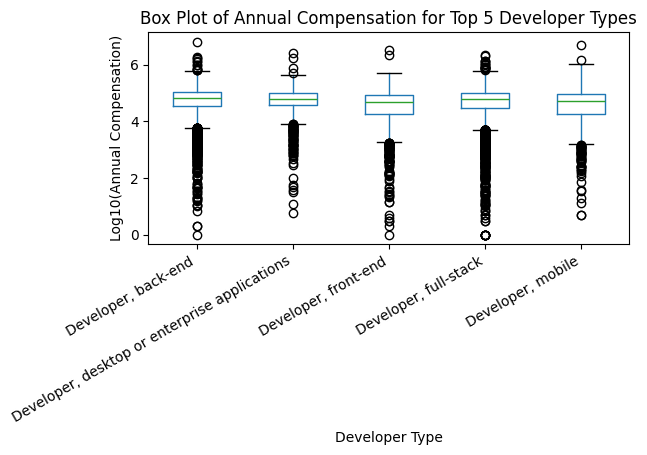

In [19]:
# your code goes here
# Load required columns
QUERY = "SELECT DevType, ConvertedCompYearly FROM main"
df = pd.read_sql_query(QUERY, conn)

# Clean compensation
df["ConvertedCompYearly"] = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce")
df = df.dropna(subset=["DevType", "ConvertedCompYearly"])
df = df[df["ConvertedCompYearly"] > 0]

# Identify top 5 developer types
top5_devtypes = df["DevType"].value_counts().head(5).index

# Filter for top 5
df_top5 = df[df["DevType"].isin(top5_devtypes)].copy()

# Log-transform compensation
df_top5["LogComp"] = np.log10(df_top5["ConvertedCompYearly"])
plt.figure(figsize=(12, 6))

df_top5.boxplot(
    column="LogComp",
    by="DevType",
    grid=False
)

plt.xlabel("Developer Type")
plt.ylabel("Log10(Annual Compensation)")
plt.title("Box Plot of Annual Compensation for Top 5 Developer Types")
plt.suptitle("")  # remove automatic subtitle
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
##The box plot shows that compensation varies significantly across developer types. Some roles exhibit 
##higher median compensation and greater variability, indicating stronger earning potential, while others show more concentrated salary ranges. 
##The presence of outliers across multiple roles suggests that seniority and specialization can lead to substantially higher earnings.

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


In [ ]:
# your code goes here
# Load required columns
QUERY = "SELECT Country, CompTotal FROM main"
df = pd.read_sql_query(QUERY, conn)

# Convert compensation to numeric
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")

# Drop invalid rows
df = df.dropna(subset=["Country", "CompTotal"])
df = df[df["CompTotal"] > 0]

# Optional: cap extreme outliers for readability
df = df[df["CompTotal"] <= 5_000_000]

# Identify top 5 countries by respondent count
top5_countries = df["Country"].value_counts().head(5).index

# Filter to top 5 countries
df_top5 = df[df["Country"].isin(top5_countries)].copy()

# Log-transform compensation
df_top5["LogComp"] = np.log10(df_top5["CompTotal"])
plt.figure(figsize=(12, 6))

df_top5.boxplot(
    column="LogComp",
    by="Country",
    grid=False
)

plt.xlabel("Country")
plt.ylabel("Log10(Total Compensation)")
plt.title("Box Plot of Total Compensation for Top 5 Countries")
plt.suptitle("")  # remove automatic subtitle
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
##The box plot shows that compensation varies significantly across the top five countries. Some countries exhibit 
##higher median compensation and greater variability, reflecting stronger technology markets and higher living costs. The presence of high-end outliers indicates that
##a subset of respondents earns substantially more than the typical compensation level within each country.

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


<Figure size 1200x600 with 0 Axes>

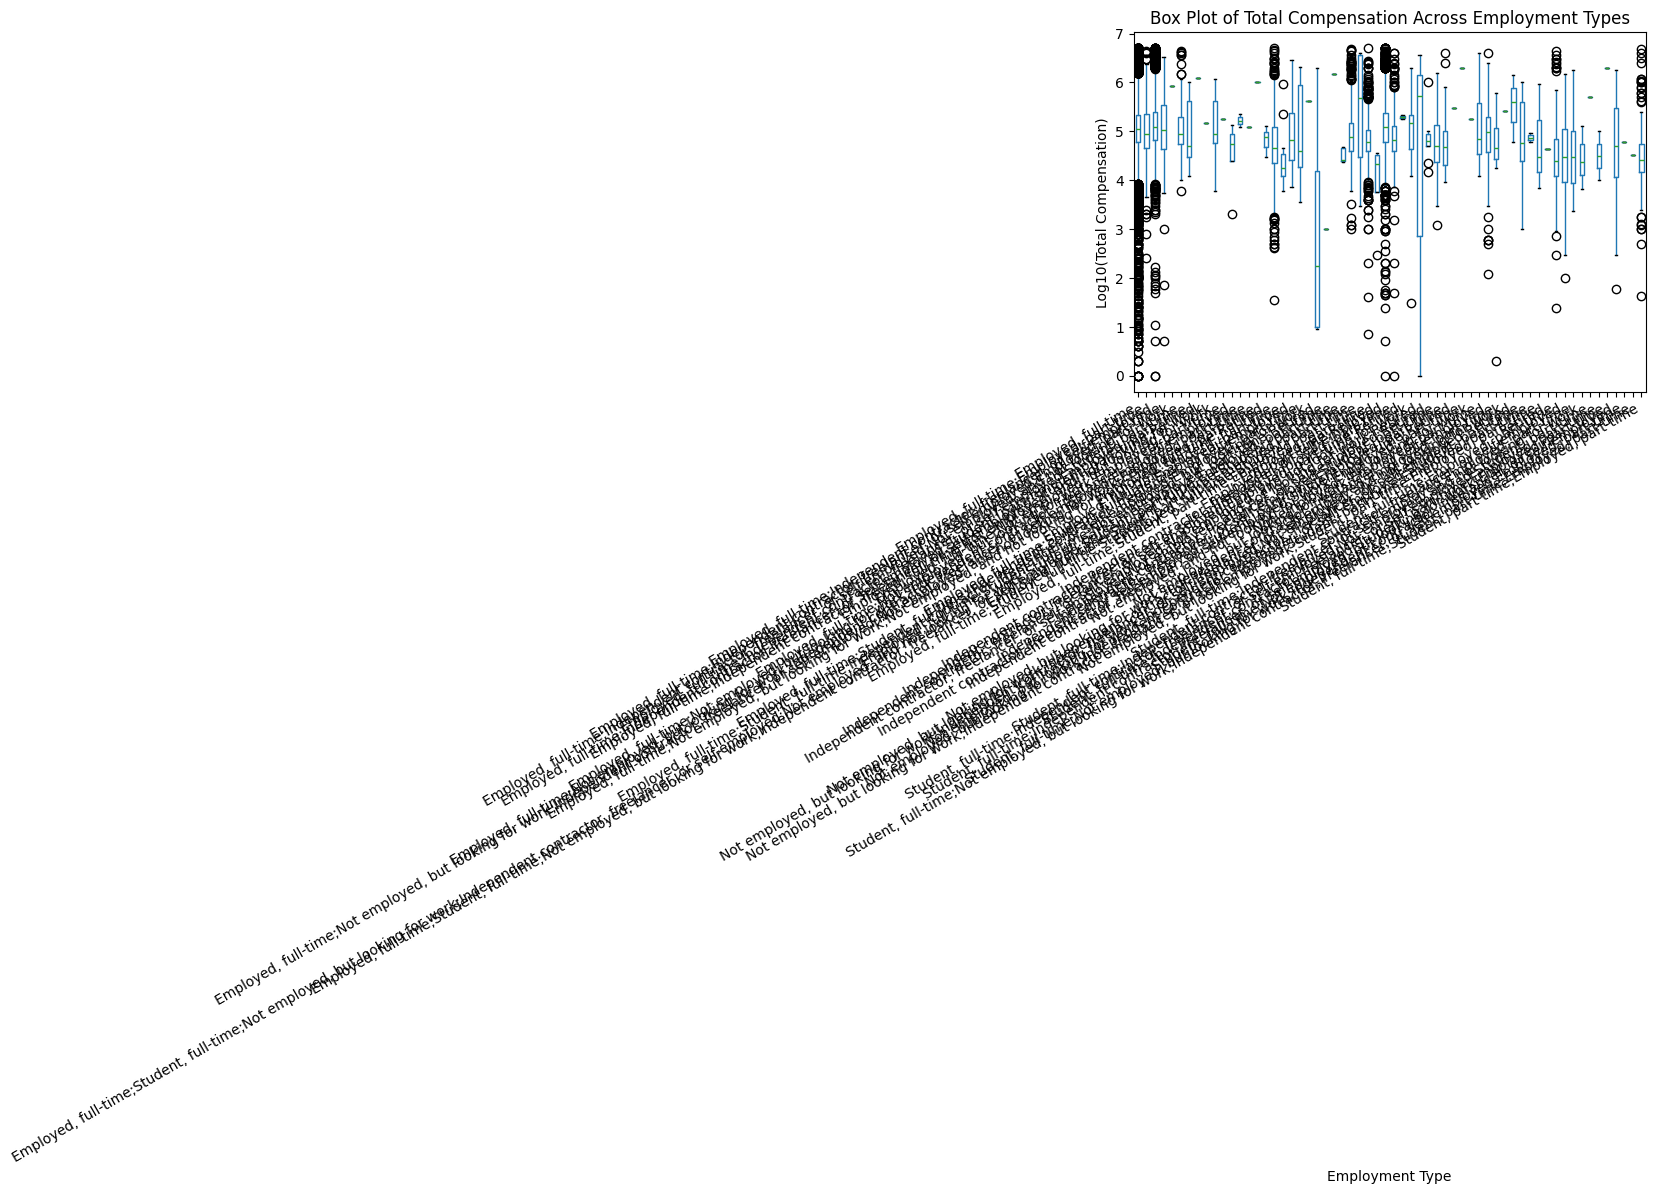

In [16]:
# your code goes here
# Load required columns
QUERY = "SELECT Employment, CompTotal FROM main"
df = pd.read_sql_query(QUERY, conn)

# Convert compensation to numeric
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")

# Drop invalid rows
df = df.dropna(subset=["Employment", "CompTotal"])
df = df[df["CompTotal"] > 0]

# Optional: cap extreme outliers for clarity
df = df[df["CompTotal"] <= 5_000_000]

# Log-transform compensation
df["LogComp"] = np.log10(df["CompTotal"])
plt.figure(figsize=(12, 6))

df.boxplot(
    column="LogComp",
    by="Employment",
    grid=False
)

plt.xlabel("Employment Type")
plt.ylabel("Log10(Total Compensation)")
plt.title("Box Plot of Total Compensation Across Employment Types")
plt.suptitle("")  # remove automatic subtitle
plt.xticks(rotation=30, ha="right")
##plt.tight_layout()
plt.show()
##The box plot shows that compensation varies significantly across employment 
##types. Full-time employees generally have higher and more consistent compensation, while self-employed
##and contract roles exhibit greater variability and more high-income outliers, reflecting differences in income stability and earning potential.

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [ ]:
# your code goes here
# Ensure CompTotal is numeric
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")

# Drop invalid rows
df_plot = df.dropna(subset=["CompTotal", "JobSatPoints_6"]).copy()
df_plot = df_plot[df_plot["CompTotal"] > 0]

# Optional but recommended: log-transform compensation
df_plot["LogCompTotal"] = np.log10(df_plot["CompTotal"])
plt.figure(figsize=(10, 6))

df_plot.boxplot(
    column="LogCompTotal",
    by="JobSatPoints_6",
    grid=False
)

plt.xlabel("Job Satisfaction Level (JobSatPoints_6)")
plt.ylabel("Log10(Total Compensation)")
plt.title("Box Plot of Total Compensation by Job Satisfaction Level")
plt.suptitle("")  # remove automatic pandas subtitle
plt.tight_layout()
plt.show()
##The box plot shows that median compensation generally increases with higher job satisfaction levels. However, 
##the wide spread and overlapping distributions across satisfaction categories indicate that 
##compensation alone does not fully explain job satisfaction, and other factors likely contribute to overall satisfaction.

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [ ]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
